# 01 - CICIDS2017 Data Exploration

**Goal**: Understand what the DDoS and Port Scan CSVs look like *before* we commit to a feature set or a model. We are specifically hunting for the known CICIDS2017 quirks:

1. Leading whitespace in column names (e.g., `" Destination Port"`)
2. `Infinity` / `NaN` values in rate columns
3. Duplicate rows
4. Class imbalance (benign ≫ attacks)

**Outputs** (consumed by later notebooks + the report):
- `../report/figures/01_class_distribution.png`
- A written findings section at the bottom of this notebook

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
FIG_DIR  = Path('../report/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

DDOS_CSV     = DATA_DIR / 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
PORTSCAN_CSV = DATA_DIR / 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'

assert DDOS_CSV.exists(),     f'Missing: {DDOS_CSV}. See data/README.md.'
assert PORTSCAN_CSV.exists(), f'Missing: {PORTSCAN_CSV}. See data/README.md.'
print('Files located.')

Files located.


## 1. Load the two days

We load each CSV, immediately strip whitespace from column names, and tag each row with the source file so we can always split them back out.

In [2]:
def load_cicids_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()  # CICIDS2017 quirk #1
    df['source_file'] = path.name
    return df

ddos_df     = load_cicids_csv(DDOS_CSV)
portscan_df = load_cicids_csv(PORTSCAN_CSV)

print(f'DDoS file:      {ddos_df.shape[0]:>9,} rows × {ddos_df.shape[1]} cols')
print(f'Port Scan file: {portscan_df.shape[0]:>9,} rows × {portscan_df.shape[1]} cols')

DDoS file:        225,745 rows × 80 cols
Port Scan file:   286,467 rows × 80 cols


In [3]:
# Peek at schema. CICIDS2017 has ~79 flow features + 1 label column.
print(f'Total columns: {len(ddos_df.columns)}')
print()
print('First 15 columns:')
for c in ddos_df.columns[:15]:
    print(f'  {c}')
print('...')
print('Last 5 columns:')
for c in ddos_df.columns[-5:]:
    print(f'  {c}')

Total columns: 80

First 15 columns:
  Destination Port
  Flow Duration
  Total Fwd Packets
  Total Backward Packets
  Total Length of Fwd Packets
  Total Length of Bwd Packets
  Fwd Packet Length Max
  Fwd Packet Length Min
  Fwd Packet Length Mean
  Fwd Packet Length Std
  Bwd Packet Length Max
  Bwd Packet Length Min
  Bwd Packet Length Mean
  Bwd Packet Length Std
  Flow Bytes/s
...
Last 5 columns:
  Idle Std
  Idle Max
  Idle Min
  Label
  source_file


## 2. Data-quality audit

The three known CICIDS2017 hazards. We count them per file; we do NOT fix them here, that belongs in `02_feature_engineering.ipynb`. Knowing the scale first helps us decide whether dropping is safe or we need imputation.

In [4]:
def quality_audit(df: pd.DataFrame, name: str) -> dict:
    numeric_df = df.select_dtypes(include=[np.number])
    nan_count      = int(df.isna().sum().sum())
    inf_count      = int(np.isinf(numeric_df.to_numpy()).sum())
    duplicate_rows = int(df.duplicated().sum())
    return {
        'file': name,
        'rows': len(df),
        'nan_cells': nan_count,
        'inf_cells': inf_count,
        'duplicate_rows': duplicate_rows,
        'duplicate_pct': round(100 * duplicate_rows / len(df), 2),
    }

audit = pd.DataFrame([
    quality_audit(ddos_df, 'DDoS'),
    quality_audit(portscan_df, 'PortScan'),
])
audit

,file,rows,nan_cells,inf_cells,duplicate_rows,duplicate_pct
0,DDoS,225745,4,64,2633,1.17
1,PortScan,286467,15,727,72353,25.26


In [6]:
# Which columns hold the Infinity values? (Usually rate columns: Flow Bytes/s, Flow Packets/s.)
def columns_with_inf(df: pd.DataFrame) -> pd.Series:
    numeric_df = df.select_dtypes(include=[np.number])
    inf_mask = np.isinf(numeric_df.to_numpy())
    inf_per_col = pd.Series(inf_mask.sum(axis=0), index=numeric_df.columns)
    return inf_per_col[inf_per_col > 0].sort_values(ascending=False)

print('DDoS file - columns with Infinity:')
print(columns_with_inf(ddos_df))
print()
print('PortScan file - columns with Infinity:')
print(columns_with_inf(portscan_df))

DDoS file - columns with Infinity:
Flow Packets/s    34
Flow Bytes/s      30
dtype: int32

PortScan file - columns with Infinity:
Flow Packets/s    371
Flow Bytes/s      356
dtype: int32


## 3. Class distribution

The `Label` column is our target. We want to see:
- The label string values (exact spelling matters for mapping later)
- How imbalanced benign vs. attack is (this dictates `class_weight` later)

In [7]:
print('DDoS file - unique labels:')
print(ddos_df['Label'].value_counts())
print()
print('PortScan file - unique labels:')
print(portscan_df['Label'].value_counts())

DDoS file - unique labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

PortScan file - unique labels:
Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


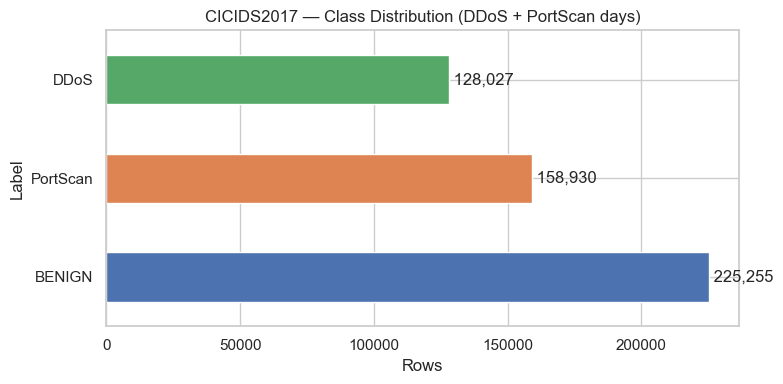

Saved: ..\report\figures\01_class_distribution.png


In [ ]:
# Combined view + save figure for the report.
combined_labels = pd.concat([
    ddos_df['Label'],
    portscan_df['Label'],
], ignore_index=True)
label_counts = combined_labels.value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('CICIDS2017 - Class Distribution (DDoS + PortScan days)')
ax.set_xlabel('Rows')
ax.set_ylabel('Label')
for i, v in enumerate(label_counts.values):
    ax.text(v, i, f' {v:,}', va='center')
plt.tight_layout()

out_path = FIG_DIR / '01_class_distribution.png'
fig.savefig(out_path, dpi=120)
plt.show()
print(f'Saved: {out_path}')

## 4. Sanity-check a few numeric columns

A full `describe()` on 78 columns is hard to read. We sample the columns most likely to carry signal for DDoS / Port Scan: `Flow Duration`, `Total Fwd Packets`, `Flow Packets/s`, `Flow Bytes/s`, and `SYN Flag Count`.

In [9]:
signal_cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Flow Packets/s',
    'Flow Bytes/s',
    'SYN Flag Count',
]
# Keep only columns that actually exist (schema drift guard).
signal_cols = [c for c in signal_cols if c in ddos_df.columns]

# We pd.concat the two files so we can describe them together, grouped by Label.
combined = pd.concat([ddos_df, portscan_df], ignore_index=True)
combined[signal_cols + ['Label']].groupby('Label').describe().T

c:\Users\gusta\Desktop\Classes\Networking & Telecomm\Final Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\gusta\Desktop\Classes\Networking & Telecomm\Final Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\gusta\Desktop\Classes\Networking & Telecomm\Final Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\gusta\Desktop\Classes\Networking & Telecomm\Final Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\gusta\Desktop\Classes\Networking & Telecomm\Final Project\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWa

Label                          BENIGN          DDoS      PortScan
Flow Duration     count  2.252550e+05  1.280270e+05  1.589300e+05
                  mean   1.342272e+07  1.695559e+07  8.282023e+04
                  std    3.184872e+07  3.101261e+07  2.325855e+06
                  min   -1.300000e+01  0.000000e+00  0.000000e+00
                  25%    2.130000e+02  6.130930e+05  4.200000e+01
                  50%    5.011700e+04  1.878978e+06  4.700000e+01
                  75%    5.147157e+06  9.387233e+06  6.100000e+01
                  max    1.199999e+08  1.039416e+08  1.198097e+08
Total Fwd Packets count  2.252550e+05  1.280270e+05  1.589300e+05
                  mean   6.042716e+00  4.472439e+00  1.017580e+00
                  std    2.666617e+01  1.897807e+00  4.255942e-01
                  min    1.000000e+00  1.000000e+00  1.000000e+00
                  25%    1.000000e+00  3.000000e+00  1.000000e+00
                  50%    2.000000e+00  4.000000e+00  1.000000e+00
                  75%    5.000000e+00  5.000000e+00  1.000000e+00
                  max    3.119000e+03  1.100000e+01  1.500000e+02
Flow Packets/s    count  2.252550e+05  1.280270e+05  1.589300e+05
                  mean            inf           inf           inf
                  std             NaN           NaN           NaN
                  min   -2.000000e+06  3.686968e-02  3.338627e-02
                  25%    2.116316e+00  4.953561e-01  3.278689e+04
                  50%    7.097624e+01  2.590679e+00  4.255319e+04
                  75%    1.724138e+04  1.302636e+01  4.761905e+04
                  max             inf           inf           inf
Flow Bytes/s      count  2.252360e+05  1.280270e+05  1.589300e+05
                  mean            inf           inf           inf
                  std             NaN           NaN           NaN
                  min   -1.930000e+08  2.212181e-01  0.000000e+00
                  25%    1.239502e+02  7.046474e+00  1.111111e+05
                  50%    4.291345e+03  1.601068e+02  1.395349e+05
                  75%    2.448980e+05  1.699368e+04  1.860465e+05
                  max             inf           inf           inf
SYN Flag Count    count  2.252550e+05  1.280270e+05  1.589300e+05
                  mean   5.999423e-02  0.000000e+00  0.000000e+00
                  std    2.374767e-01  0.000000e+00  0.000000e+00
                  min    0.000000e+00  0.000000e+00  0.000000e+00
                  25%    0.000000e+00  0.000000e+00  0.000000e+00
                  50%    0.000000e+00  0.000000e+00  0.000000e+00
                  75%    0.000000e+00  0.000000e+00  0.000000e+00
                  max    1.000000e+00  0.000000e+00  0.000000e+00

## 5. Your findings

> **Fill this in after running the notebook**, these observations go into the PDF report and shape `02_feature_engineering.ipynb`.

- **Total rows after both files**: _512,212_
- **Class balance** (benign : DDoS : PortScan ratio): _44 : 25 : 31 (2: 1.1 : 1.4)_
- **Infinity cells found in** (which columns?): _Flow Bytes/s, Flow Packets/s (rate columns)_
- **Duplicate-row count**: _2,633 (DDoS, 1.17%) + 72,353 (PortScan, 25.26%)_
- **Biggest surprise**: _PortScan has 25% duplicates, scanning traffic collapses to identical feature vectors_

### Decisions this notebook informs

| Question for notebook 02 | What this notebook tells us |
|---|---|
| Should we downsample benign? | Depends on the ratio you wrote above. If benign > 3× attacks, probably yes. |
| How to handle Infinity? | Replace with 0 (rate was undefined → zero-duration flow). Alternative: drop. |
| Stratified split? | If classes are imbalanced, yes — non-stratified split risks a test set with zero port-scan examples. |
| Binary vs multi-class? | Three-class (benign / ddos / portscan) is fine because counts per class are all > 100k. |